In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix

In [23]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32,padding=4),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [24]:
train_data = datasets.CIFAR10(root='../Data',download=True,train=True,transform=transform_train)

Files already downloaded and verified


In [25]:
test_data = datasets.CIFAR10(root='../Data',download=True,train=False,transform=test_transform)

Files already downloaded and verified


In [26]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)

In [27]:
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

In [31]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,64,3,1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,128,3,1)
        self.bn3 = nn.BatchNorm2d(128)
        self.fc1 = nn.Linear(2*2*128,300)
        self.fc2 = nn.Linear(300,100)
        self.fc3 = nn.Linear(100,10)
        self.dropout = nn.Dropout(0.15)

    def forward(self,X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.bn3(self.conv3(X)))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,2*2*128)
        X = self.dropout(F.relu(self.fc1(X)))
        X = self.dropout(F.relu(self.fc2(X)))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [33]:
torch.manual_seed(13)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=512, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
  (dropout): Dropout(p=0.15, inplace=False)
)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [38]:
import time
start_time =time.time()

epochs = 15
training_loss = []
test_loss = []
training_correct = []
test_correct = []

for i in range(epochs):
    trn_corr=0
    tst_corr=0

    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1

        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%2500 == 0:
            print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/50000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    training_correct.append(trn_corr.item())
    training_loss.append(loss.item())

    with torch.no_grad():
        for b, (X_test,y_test) in enumerate(test_loader):
            y_val = model(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()

        loss = criterion(y_val,y_test)
        test_correct.append(tst_corr.item())
        test_loss.append(loss.item())



print(f"\nDuration: {time.time() - start_time:.0f} seconds")

epoch:  0  batch: 2500 [ 25000/50000]  loss: 0.87074506  accuracy:  52.500%
epoch:  0  batch: 5000 [ 50000/50000]  loss: 1.16583693  accuracy:  54.378%
epoch:  1  batch: 2500 [ 25000/50000]  loss: 1.30851102  accuracy:  58.088%
epoch:  1  batch: 5000 [ 50000/50000]  loss: 1.36512506  accuracy:  59.060%
epoch:  2  batch: 2500 [ 25000/50000]  loss: 0.88329870  accuracy:  61.260%
epoch:  2  batch: 5000 [ 50000/50000]  loss: 0.84376991  accuracy:  62.120%
epoch:  3  batch: 2500 [ 25000/50000]  loss: 0.77474821  accuracy:  64.452%
epoch:  3  batch: 5000 [ 50000/50000]  loss: 0.57708949  accuracy:  64.474%
epoch:  4  batch: 2500 [ 25000/50000]  loss: 0.74308890  accuracy:  65.584%
epoch:  4  batch: 5000 [ 50000/50000]  loss: 0.85888863  accuracy:  65.970%
epoch:  5  batch: 2500 [ 25000/50000]  loss: 0.43419543  accuracy:  67.504%
epoch:  5  batch: 5000 [ 50000/50000]  loss: 0.53729999  accuracy:  67.398%
epoch:  6  batch: 2500 [ 25000/50000]  loss: 0.49155921  accuracy:  68.564%
epoch:  6  b

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

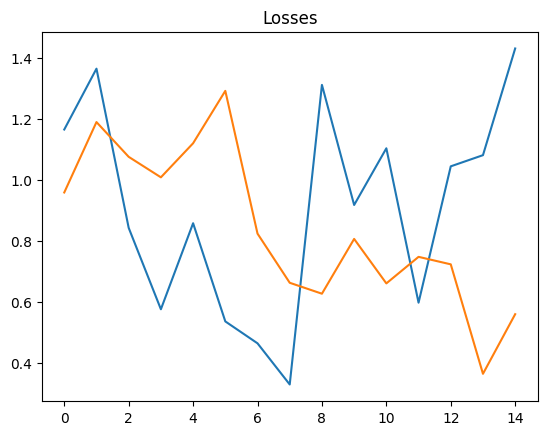

In [39]:
plt.plot(training_loss, label="Training loss")
plt.plot(test_loss,label="Test_loss")
plt.title("Losses")
plt.legend

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

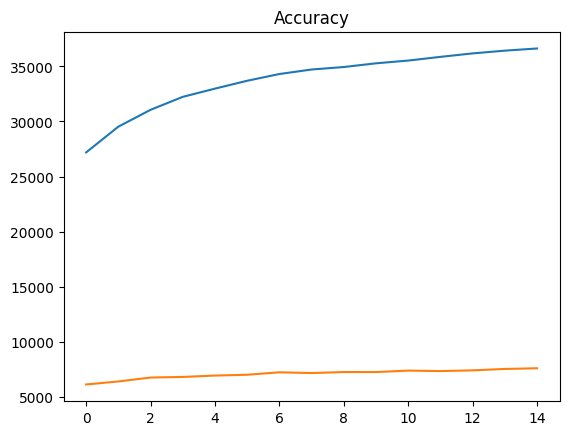

In [40]:
plt.plot(training_correct, label="Training loss")
plt.plot(test_correct,label="Test_correct")
plt.title("Accuracy")
plt.legend

In [41]:
print(f"Train Accuracy {training_correct[-1]/500:.2f}%")
print(f"Test Acuuracy {test_correct[-1]/100:.2f}%")

Train Accuracy 73.26%
Test Acuuracy 75.81%
